# Hands-on Part 1 - Classic Q-Learning
- using the gymnasium Frozen Lake
    - ![Frozen Lake](https://gymnasium.farama.org/_images/frozen_lake.gif)
        - Credit: image from https://gymnasium.farama.org

## Setup and Imports

In [1]:
!pip install "gymnasium[toy-text]"

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import pygame

## Environment Setup

In [3]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)

Action space: Discrete(4)
Observation space: Discrete(16)


## Initialize Q-table

In [4]:
state_size = env.observation_space.n
action_size = env.action_space.n
qtable = np.zeros((state_size, action_size))
print("Q-table shape:", qtable.shape)
print("Initial Q-table:")
print(qtable)

Q-table shape: (16, 4)
Initial Q-table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Q-learning Parameters

In [5]:
learning_rate = 0.8
discount_factor = 0.95
epochs = 1000
epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.001

## Training Loop with Live Updates

In [6]:
rewards = []

for episode in range(epochs):
    state, info = env.reset()
    total_rewards = 0
    
    while True:
        # Exploration vs Exploitation
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(qtable[state, :])  # Exploit
        
        # Take action
        new_state, reward, terminated, truncated, info = env.step(action)
        
        # Q-learning update
        qtable[state, action] = qtable[state, action] + learning_rate * (
            reward + discount_factor * np.max(qtable[new_state, :]) - qtable[state, action]
        )
        
        total_rewards += reward
        state = new_state
        
        if terminated or truncated:
            break
    
    # Epsilon decay
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards.append(total_rewards)
    
    # Progress update every 100 episodes
    if episode % 100 == 0:
        #clear_output(wait=True)
        print(f"Episode: {episode}, Epsilon: {epsilon:.3f}")
        print(f"Success rate (last 100): {np.mean(rewards[-100:]):.2f}")

print("\nTraining completed!")

Episode: 0, Epsilon: 1.000
Success rate (last 100): 0.00
Episode: 100, Epsilon: 0.906
Success rate (last 100): 0.01
Episode: 200, Epsilon: 0.821
Success rate (last 100): 0.02
Episode: 300, Epsilon: 0.743
Success rate (last 100): 0.13
Episode: 400, Epsilon: 0.674
Success rate (last 100): 0.16
Episode: 500, Epsilon: 0.610
Success rate (last 100): 0.22
Episode: 600, Epsilon: 0.553
Success rate (last 100): 0.26
Episode: 700, Epsilon: 0.502
Success rate (last 100): 0.34
Episode: 800, Epsilon: 0.455
Success rate (last 100): 0.43
Episode: 900, Epsilon: 0.413
Success rate (last 100): 0.63

Training completed!


## Visualize Learning Progress

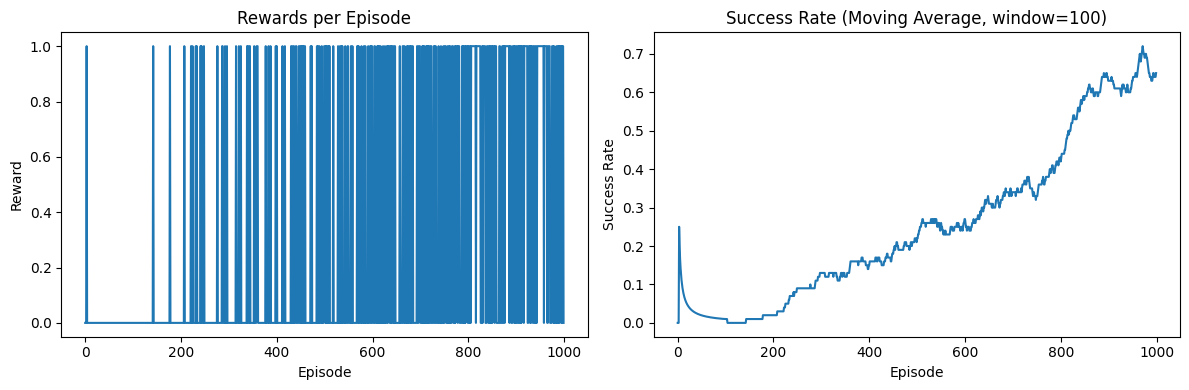

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rewards)
plt.title("Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.subplot(1, 2, 2)
# Moving average
moving_avg = [np.mean(rewards[i-100:i]) if i >= 100 else np.mean(rewards[:i+1]) 
              for i in range(len(rewards))]
plt.plot(moving_avg)
plt.title("Success Rate (Moving Average, window=100)")
plt.xlabel("Episode")
plt.ylabel("Success Rate")

plt.tight_layout()
plt.show()

## Inspect the Final Q-table
- Each row = a state (0..15).
- Each column = an action (0..3) corresponding to ['←','↓','→','↑'] in your notebook.
- Each number = Q(s,a): the expected (discounted) return of taking that action in that state and following the learned policy afterward. Higher = better.

In [8]:
print("Final Q-table:")
print(qtable)

print("\nOptimal policy (action to take in each state):")
for state in range(state_size):
    best_action = np.argmax(qtable[state, :])
    action_symbol = ['←', '↓', '→', '↑'][best_action]
    print(f"State {state}: {action_symbol} (action {best_action})")

Final Q-table:
[[0.73509189 0.77378094 0.77378094 0.73509189]
 [0.73509189 0.         0.81450625 0.77378094]
 [0.77378094 0.857375   0.77378094 0.81450625]
 [0.81450625 0.         0.77378055 0.77375645]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.81450625]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.857375   0.95       0.         0.857375  ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]

Optimal policy (action to take in each state):
State 0: ↓ (action 1)
State 1: → (action 2)
State 2: ↓ (action 1)
State 3: ← (action 0)
State 4: ↓ (action 1)
State 5: ← (action 0)
State 6: ↓ (action 1)
State 7: ← (action 0)
State 8:

## Test the Trained Agent

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
state, info = env.reset()
env.render()

total_rewards = 0

while True:
    action = np.argmax(qtable[state, :])  # Always exploit
    state, reward, terminated, truncated, info = env.step(action)
    total_rewards += reward
    env.render()
    time.sleep(0.5)  # Slow down to watch
    
    if terminated or truncated:
        break

print(f"Total reward: {total_rewards}")
env.close()
pygame.display.quit()
pygame.quit()

Total reward: 1


: 